In [7]:
import matplotlib.pyplot as plt

import os
import sys

from copy import deepcopy

import torch
from torch.utils.data import DataLoader, random_split

parent = os.path.abspath("..")
if parent not in sys.path:
    sys.path.append(parent)

from src.config import settings
import src.modeling.translation_model as basemodel


In [18]:
beta1 = settings.BETA1
workers = settings.WORKERS
batch_size = settings.BATCH_SIZE
num_epochs = settings.NUM_EPOCHS
learning_rate = settings.LEARNING_RATE
ratio_validation = settings.RATIO_VALIDATION
characters_lowercase = settings.CHARACTERS_LOWERCASE

transform = deepcopy(basemodel.transform)
ngpus = basemodel.ngpus
device = basemodel.device

SAVE_PATH = settings.SAVE_PATH

learning_rate = settings.LEARNING_RATE
beta1 = settings.BETA1

## Custom Dataset

In [9]:
custom_dataset = basemodel.CustomDataset(
    root="../data/processed/kaggle", transform=transform
)
dataloader = DataLoader(
    custom_dataset, batch_size=batch_size, shuffle=True, num_workers=workers
)

In [10]:
data_iter = iter(dataloader)
images, labels = next(data_iter)
print(f"images shape: {images.shape}")
print(f"labels shape: {labels.shape}")

images shape: torch.Size([128, 1, 28, 28])
labels shape: torch.Size([128])


In [11]:
train_size = int(len(custom_dataset) * (1 - ratio_validation))
validation_size = len(custom_dataset) - train_size

dataset_train, dataset_val = random_split(
    custom_dataset, [train_size, validation_size], generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

# Train set
data_iter = iter(train_loader)
images, labels = next(data_iter)
print("TRAIN")
print(f"\ttrain size: {train_size}")
print(f"\timages shape: {images.shape}")
print(f"\tlabels shape: {labels.shape}")

# Validation set
data_iter = iter(val_loader)
images, labels = next(data_iter)
print("\nVALIDATION")
print(f"\tvalidation size: {validation_size}")
print(f"\timages shape: {images.shape}")
print(f"\tlabels shape: {labels.shape}")

TRAIN
	train size: 21060
	images shape: torch.Size([128, 1, 28, 28])
	labels shape: torch.Size([128])

VALIDATION
	validation size: 7020
	images shape: torch.Size([128, 1, 28, 28])
	labels shape: torch.Size([128])


## Translation CNN

In [12]:
net = deepcopy(basemodel.net)
criterion = deepcopy(basemodel.criterion)
optimizer = deepcopy(basemodel.optimizer)

### Train

In [ ]:
losses = []
accuracies = []
best_loss = float("inf")
miniepochs = 0

for epoch in range(num_epochs):
    for i, (inputs, labels) in enumerate(train_loader, 0):
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        correct = (predicted == labels).sum().item()
        accuracy = correct / labels.size(0)

        # Stats
        losses.append(loss.item())
        accuracies.append(accuracy)

        if loss < best_loss:
            best_loss = loss
            best_model = {
                "epoch": epoch,
                "model_state_dict": net.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": loss,
                "accuracy": accuracy,
            }

        miniepochs += 1
        if miniepochs % settings.MINI_BATCHES == 0:
            print(
                f"{miniepochs}. [{epoch + 1}, {i + 1:2d}] loss: {loss.item():.3f} -- accuracy: {accuracy:.3f}"
            )

print("Finished Training")

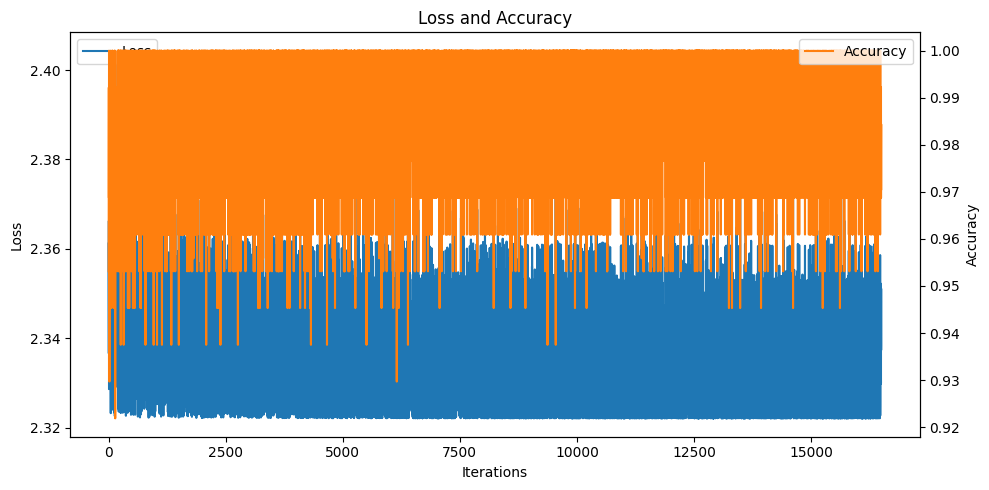

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set(title="Loss and Accuracy", xlabel="Iterations", ylabel="Loss")
ax1.plot(losses, label="Loss", color="tab:blue")

ax2 = ax1.twinx()
ax2.set(ylabel="Accuracy")
ax2.plot(accuracies, label="Accuracy", color="tab:orange")

fig.tight_layout()
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()

### Save

In [16]:
filename = f'best_model_epoch{best_model["epoch"]}.pth'
save_path = os.path.join(basemodel.get_save_path(), filename)
torch.save(best_model, save_path)

## Validate & Load

1st version. This must be upgraded

In [23]:
save_path = "../models/runs/translation/train4/best_model_epoch92.pth"

In [24]:
checkpoint = torch.load(save_path, weights_only=True)
net.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
epoch = checkpoint["epoch"]
loss = checkpoint["loss"]
accuracy = checkpoint["accuracy"]
print(f"Cargado modelo de la época {epoch}, con pérdida {loss:.4f} y exactitud {accuracy:.4%}")

Cargado modelo de la época 92, con pérdida 2.3221 y exactitud 100.0000%


Accuracy of the network on the 7020 test images: 98.828125%


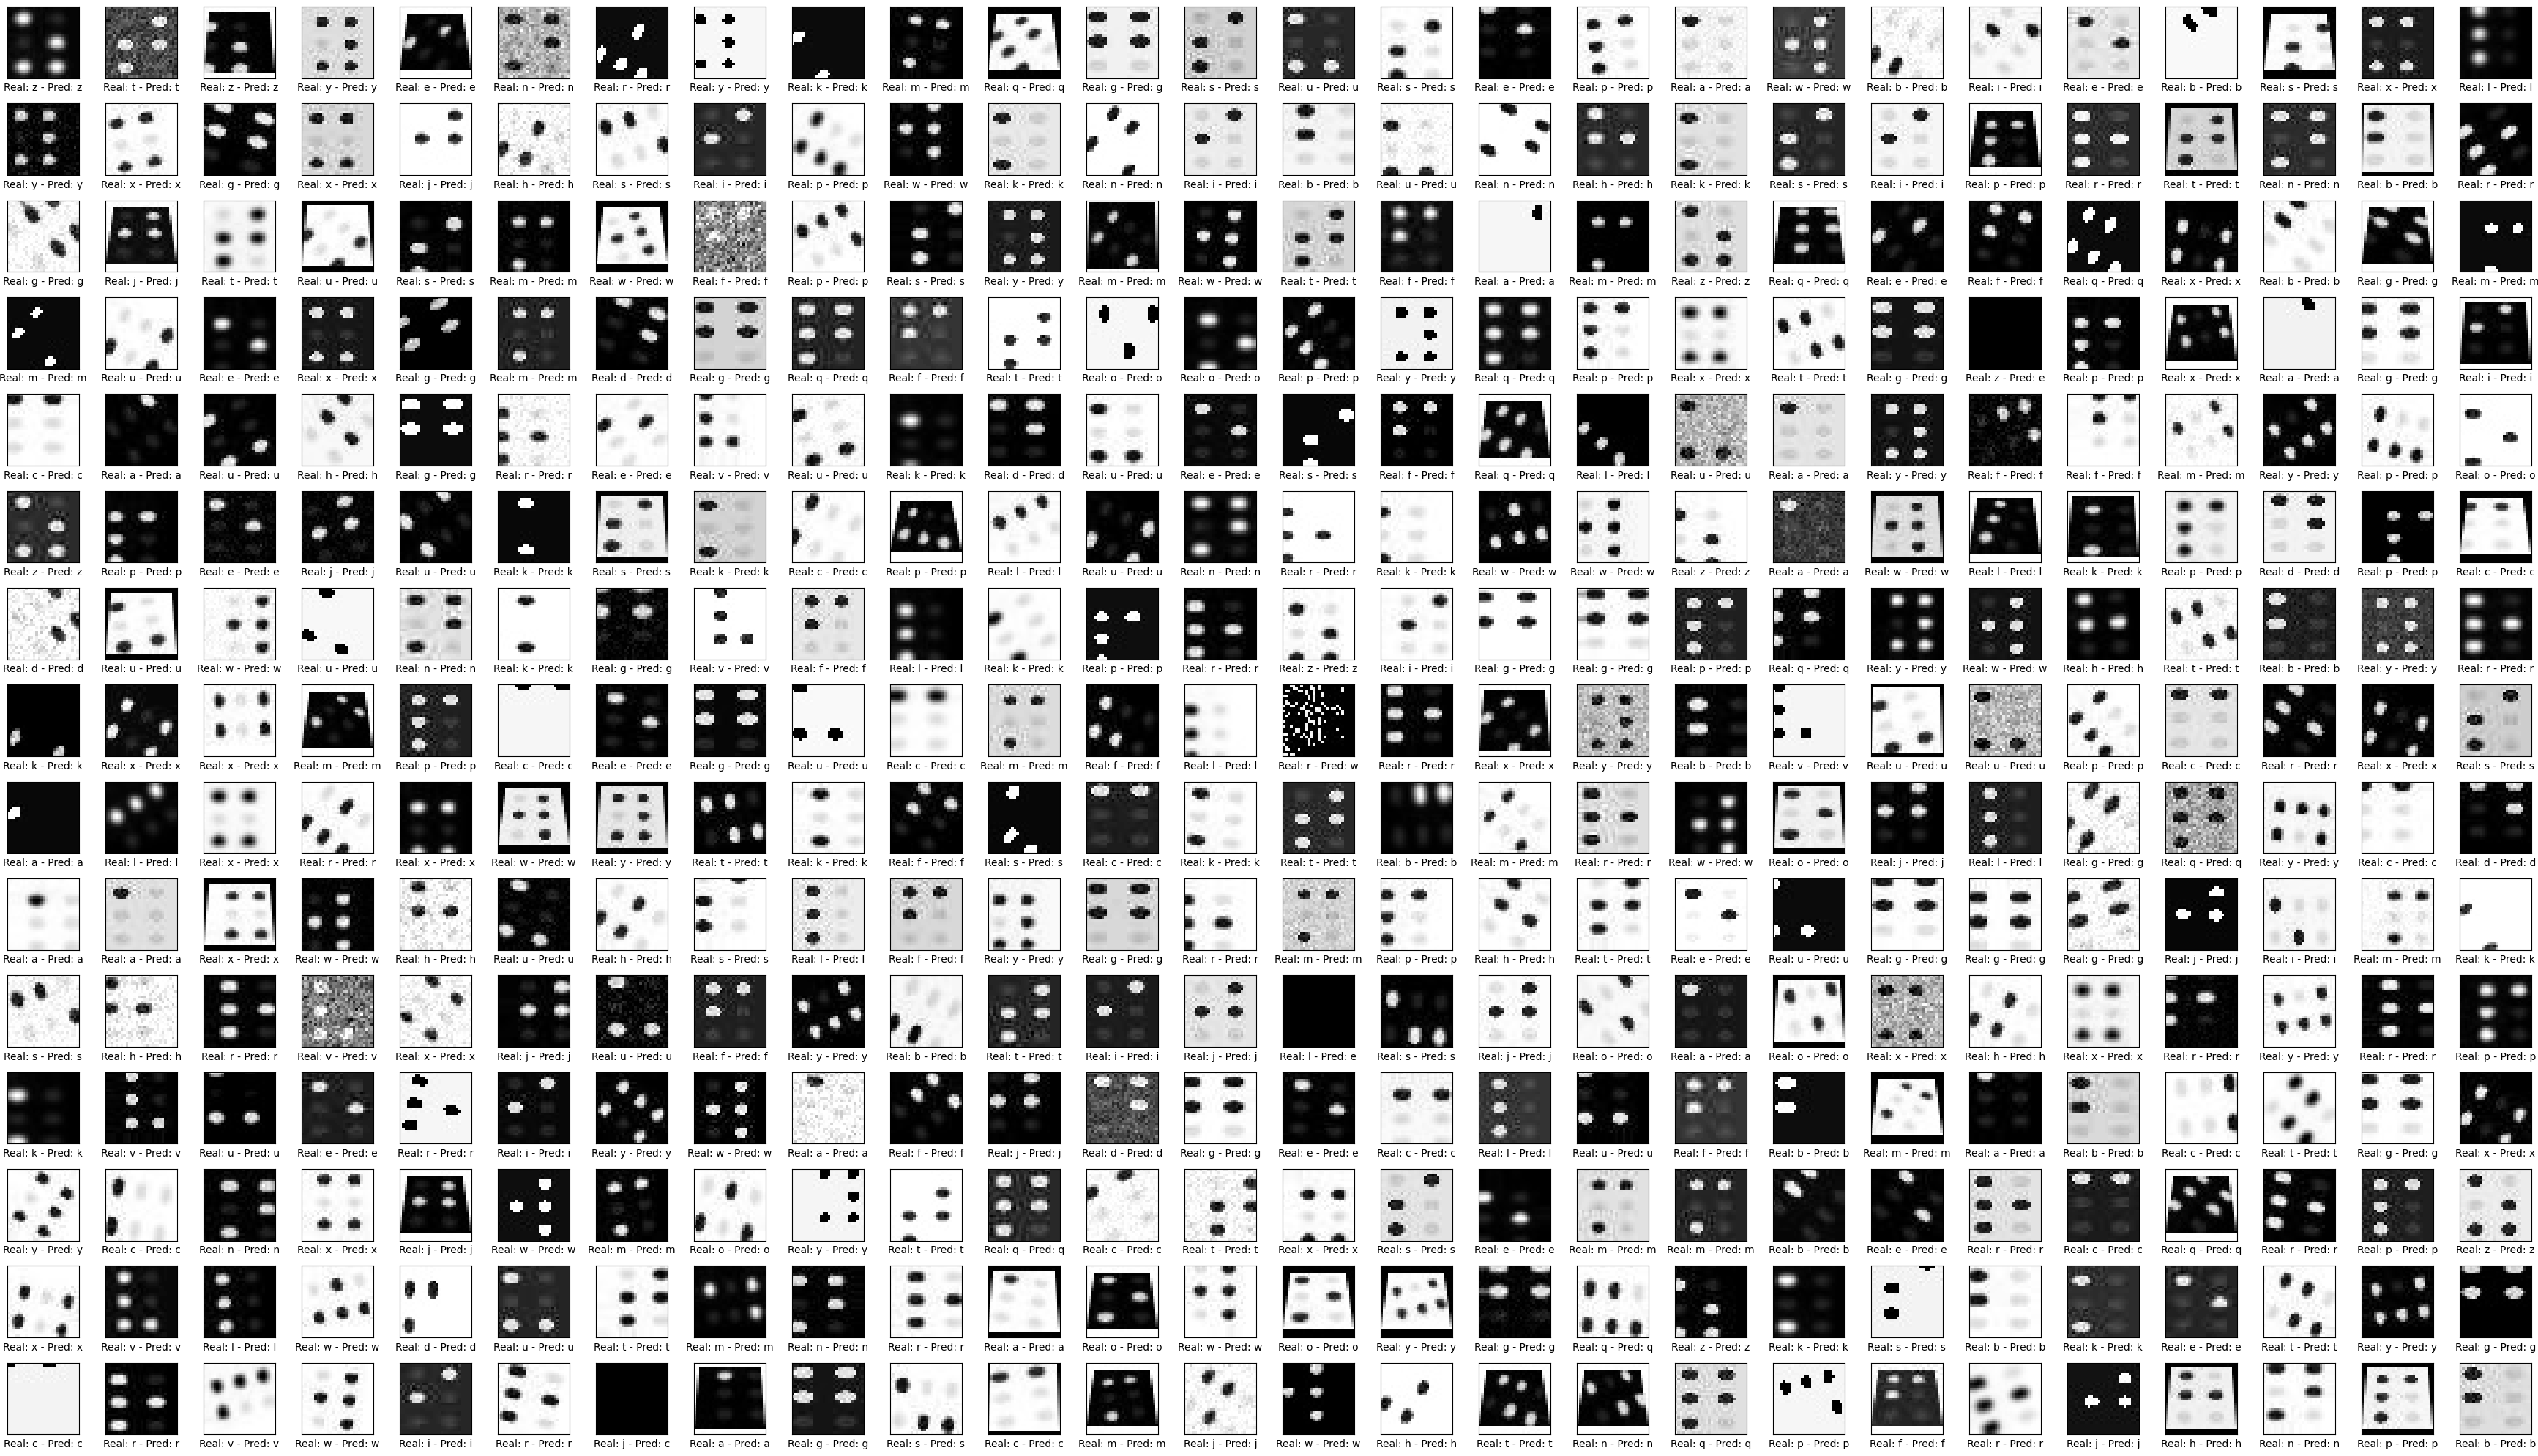

In [25]:
fig, axes = plt.subplots(15, 26, figsize=(35, 20))

dataiter = iter(val_loader)
images, labels = next(dataiter)

correct = 0
total = 0

axes_flatten = axes.flatten()
cont = 0
with torch.no_grad():
    for data in val_loader:
        images, labels = data

        # calculate outputs by running images through the network
        outputs = net(images)

        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        images = images.numpy().reshape(
            images.shape[0], images.shape[2], images.shape[3]
        )  # (batch_size, height, width)

        try:
            for i in range(images.shape[0]):
                img = images[i, :, :]

                ax = axes_flatten[cont]

                character_predicted = characters_lowercase[predicted[i]]
                character_label = characters_lowercase[labels[i]]
                ax.set(
                    xticks=[], yticks=[],
                    xlabel=f"Real: {character_label} - Pred: {character_predicted}"
                )
                ax.imshow(img, cmap="gray")
                cont += 1
        except IndexError:
            break

print(f"Accuracy of the network on the {validation_size} test images: {correct / total:%}")

fig.tight_layout()
plt.show()